# NIFTY 100 Financial Intelligence

## Day 7 — Exploratory Financial Analysis

This notebook performs exploratory data analysis on the calculated financial metrics and company rankings.

### Analysis Objectives

- Analyse company financial performance
- Compare financial growth metrics
- Explore company scores
- Identify top-ranked companies
- Analyse score distributions
- Generate financial intelligence insights

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries imported successfully")

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries imported successfully")

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
PROJECT_ROOT = Path.cwd().parent

METRICS_FILE = PROJECT_ROOT / "output" / "company_financial_metrics.csv"
RANKINGS_FILE = PROJECT_ROOT / "output" / "company_rankings.csv"

metrics_df = pd.read_csv(METRICS_FILE)
rankings_df = pd.read_csv(RANKINGS_FILE)

print("Financial metrics loaded successfully")
print(f"Metrics shape  : {metrics_df.shape}")
print(f"Rankings shape : {rankings_df.shape}")

display(metrics_df.head())

Financial metrics loaded successfully
Metrics shape  : (92, 33)
Rankings shape : (92, 12)


,company_id,company_name,roce_percentage,roe_percentage,latest_financial_year,latest_sales,latest_operating_profit,latest_net_profit,latest_eps,operating_margin_percentage,net_profit_margin_percentage,latest_reserves,latest_borrowings,latest_total_liabilities,latest_total_assets,debt_to_asset_ratio,latest_operating_cash_flow,latest_net_cash_flow,compounded_sales_growth,compounded_profit_growth,stock_price_cagr,roe,sales_growth_score,profit_growth_score,stock_cagr_score,roe_score,roce_score,profit_margin_score,cash_flow_score,debt_score,financial_health_score,financial_rating,company_rank
0,ITC,ITC Ltd,34.76,29.47,NaN,75135,26640.0,20829,16.0,35.456179,27.722100,74015.0,304.0,94071.0,94071.0,0.003232,17179.0,191.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.666667,87.912088,89.130435,76.923077,87.912088,85.71,EXCELLENT,1
1,COALINDIA,Coal India Ltd,63.60,52.00,NaN,140328,93717.0,34350,56.0,66.784248,24.478365,90034.0,7816.0,249359.0,249359.0,0.031344,18103.0,-282.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.555556,95.604396,83.695652,78.021978,71.428571,84.86,EXCELLENT,2
2,INFY,Infosys Ltd,40.00,31.80,NaN,159988,38145.0,27687,67.0,23.842413,17.305673,88391.0,8804.0,141870.0,141870.0,0.062057,25210.0,2613.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.888889,90.109890,65.217391,86.813187,64.835165,79.17,STRONG,3
3,ABB,Abbott India Ltd,46.00,34.90,NaN,6066,1547.0,1285,605.0,25.502803,21.183647,3500.0,60.0,5063.0,5063.0,0.011851,6038.0,551.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.111111,92.307692,75.000000,52.197802,82.417582,78.61,STRONG,4
4,LICI,Life Insurance Corporation of India,63.79,63.61,NaN,896106,25851.0,41468,NaN,2.884815,4.627578,91312.0,10.0,5719121.0,5719121.0,0.000002,26122.0,-3574.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.888889,96.703297,13.043478,87.912088,94.505495,78.21,STRONG,5


In [3]:
print("=" * 70)
print("FINANCIAL METRICS DATASET OVERVIEW")
print("=" * 70)

print("\nMetrics columns:")
for index, column in enumerate(metrics_df.columns, start=1):
    print(f"{index:02d}. {column}")

print("\n" + "=" * 70)
print("MISSING VALUE SUMMARY")
print("=" * 70)

missing_summary = (
    metrics_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"] / len(metrics_df) * 100
).round(2)

display(missing_summary[missing_summary["missing_values"] > 0])

print("\nDataset inspection completed")

FINANCIAL METRICS DATASET OVERVIEW

Metrics columns:
01. company_id
02. company_name
03. roce_percentage
04. roe_percentage
05. latest_financial_year
06. latest_sales
07. latest_operating_profit
08. latest_net_profit
09. latest_eps
10. operating_margin_percentage
11. net_profit_margin_percentage
12. latest_reserves
13. latest_borrowings
14. latest_total_liabilities
15. latest_total_assets
16. debt_to_asset_ratio
17. latest_operating_cash_flow
18. latest_net_cash_flow
19. compounded_sales_growth
20. compounded_profit_growth
21. stock_price_cagr
22. roe
23. sales_growth_score
24. profit_growth_score
25. stock_cagr_score
26. roe_score
27. roce_score
28. profit_margin_score
29. cash_flow_score
30. debt_score
31. financial_health_score
32. financial_rating
33. company_rank

MISSING VALUE SUMMARY


,missing_values,missing_percentage
latest_financial_year,92,100.00
roe,92,100.00
stock_cagr_score,92,100.00
sales_growth_score,92,100.00
profit_growth_score,92,100.00
compounded_profit_growth,92,100.00
stock_price_cagr,92,100.00
compounded_sales_growth,92,100.00
roe_score,2,2.17
roe_percentage,2,2.17



Dataset inspection completed


In [4]:
# ============================================================
# FINANCIAL SCORE DISTRIBUTION ANALYSIS
# ============================================================

score_columns = [
    "sales_growth_score",
    "profit_growth_score",
    "stock_cagr_score",
    "roe_score",
    "roce_score",
    "cash_flow_score",
    "debt_score",
]

available_score_columns = [
    column
    for column in score_columns
    if column in metrics_df.columns
]

print("=" * 70)
print("FINANCIAL SCORE DISTRIBUTION ANALYSIS")
print("=" * 70)

print("\nAvailable score columns:")
for column in available_score_columns:
    print(f"- {column}")

score_summary = metrics_df[
    available_score_columns
].describe().T

display(score_summary)

print("\nScore distribution counts:")

for column in available_score_columns:
    print("\n" + "-" * 70)
    print(column.upper())
    print("-" * 70)

    print(
        metrics_df[column]
        .value_counts(dropna=False)
        .sort_index()
    )

print("\nFinancial score distribution analysis completed")

FINANCIAL SCORE DISTRIBUTION ANALYSIS

Available score columns:
- sales_growth_score
- profit_growth_score
- stock_cagr_score
- roe_score
- roce_score
- cash_flow_score
- debt_score


,count,mean,std,min,25%,50%,75%,max
sales_growth_score,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
profit_growth_score,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stock_cagr_score,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
roe_score,90.0,50.555556,29.026848,1.111111,25.833333,50.555556,75.277778,100.000000
roce_score,91.0,50.549451,29.024653,1.098901,25.824176,50.549451,75.274725,100.000000
cash_flow_score,91.0,50.549451,29.025577,1.098901,25.824176,50.549451,75.274725,100.000000
debt_score,91.0,49.450549,29.024422,0.000000,24.725275,49.450549,74.175824,97.252747



Score distribution counts:

----------------------------------------------------------------------
SALES_GROWTH_SCORE
----------------------------------------------------------------------
sales_growth_score
NaN    92
Name: count, dtype: int64

----------------------------------------------------------------------
PROFIT_GROWTH_SCORE
----------------------------------------------------------------------
profit_growth_score
NaN    92
Name: count, dtype: int64

----------------------------------------------------------------------
STOCK_CAGR_SCORE
----------------------------------------------------------------------
stock_cagr_score
NaN    92
Name: count, dtype: int64

----------------------------------------------------------------------
ROE_SCORE
----------------------------------------------------------------------
roe_score
1.111111      1
2.222222      1
3.333333      1
4.444444      1
5.555556      1
             ..
95.555556     1
97.222222     2
98.888889     1
100.000000    1


VALID FINANCIAL SCORE DISTRIBUTION CHARTS

Valid score columns:
- roe_score
- roce_score
- cash_flow_score
- debt_score


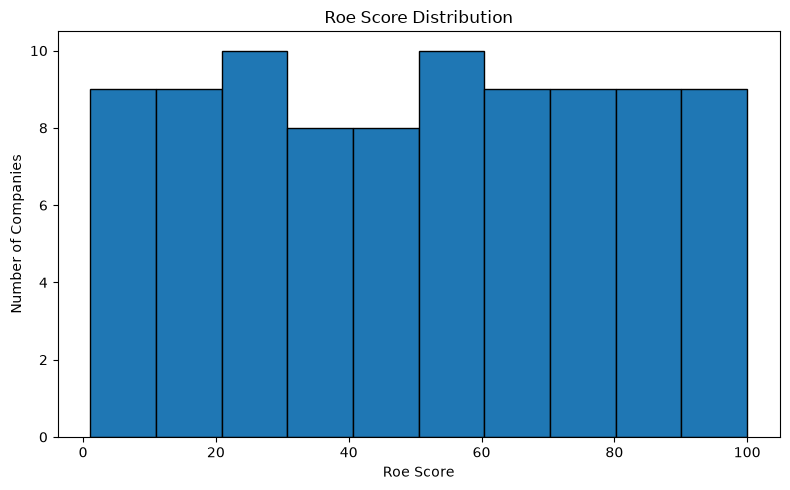

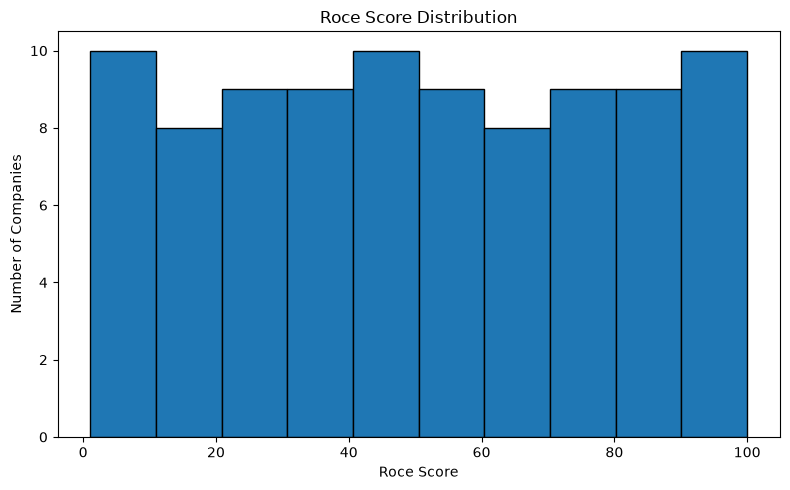

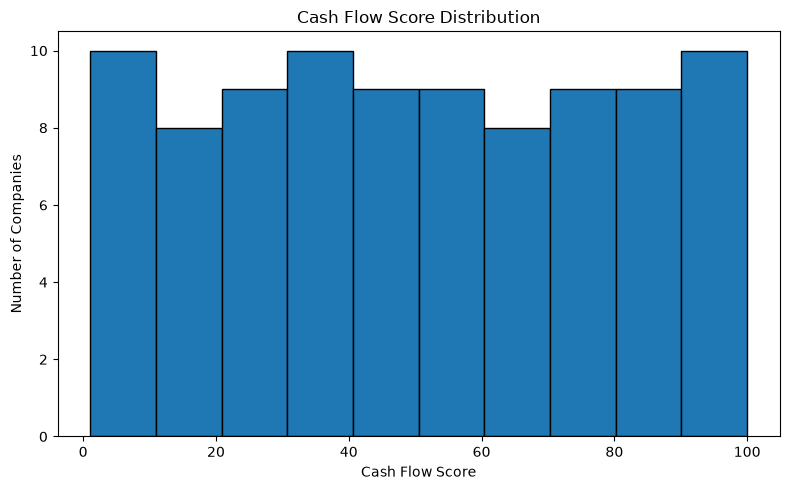

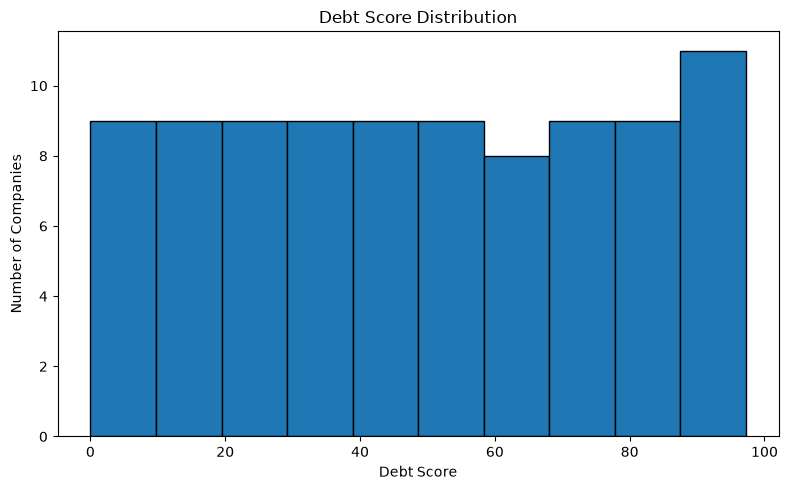


Financial score distribution charts completed


In [5]:
# ============================================================
# VALID FINANCIAL SCORE DISTRIBUTION CHARTS
# ============================================================

valid_score_columns = [
    column
    for column in available_score_columns
    if metrics_df[column].notna().any()
]

print("=" * 70)
print("VALID FINANCIAL SCORE DISTRIBUTION CHARTS")
print("=" * 70)

print("\nValid score columns:")

for column in valid_score_columns:
    print(f"- {column}")

if not valid_score_columns:
    print("\nNo valid score columns available for plotting.")

else:
    for column in valid_score_columns:
        score_data = metrics_df[column].dropna()

        plt.figure(figsize=(8, 5))

        plt.hist(
            score_data,
            bins=10,
            edgecolor="black"
        )

        plt.title(
            f"{column.replace('_', ' ').title()} Distribution"
        )

        plt.xlabel(
            column.replace("_", " ").title()
        )

        plt.ylabel("Number of Companies")

        plt.tight_layout()
        plt.show()

print("\nFinancial score distribution charts completed")

In [6]:
# ============================================================
# TOP 10 COMPANY RANKINGS ANALYSIS
# ============================================================

print("=" * 70)
print("TOP 10 COMPANY RANKINGS ANALYSIS")
print("=" * 70)

print("\nRanking columns:")

for index, column in enumerate(rankings_df.columns, start=1):
    print(f"{index:02d}. {column}")

score_column = None

for candidate in [
    "financial_score",
    "overall_score",
    "total_score",
    "score"
]:
    if candidate in rankings_df.columns:
        score_column = candidate
        break

if score_column is None:
    numeric_columns = rankings_df.select_dtypes(
        include=np.number
    ).columns.tolist()

    excluded_columns = [
        "rank",
        "company_id"
    ]

    numeric_columns = [
        column
        for column in numeric_columns
        if column not in excluded_columns
    ]

    if numeric_columns:
        score_column = numeric_columns[0]

print(f"\nSelected score column: {score_column}")

if score_column is None:
    print("\nNo score column available for ranking analysis.")

else:
    top_10_companies = (
        rankings_df
        .dropna(subset=[score_column])
        .sort_values(
            by=score_column,
            ascending=False
        )
        .head(10)
    )

    display_columns = [
        column
        for column in [
            "company_id",
            "company_name",
            score_column
        ]
        if column in top_10_companies.columns
    ]

    print("\nTop 10 companies:")
    display(top_10_companies[display_columns])

print("\nTop 10 company rankings analysis completed")

TOP 10 COMPANY RANKINGS ANALYSIS

Ranking columns:
01. company_rank
02. company_id
03. company_name
04. financial_health_score
05. financial_rating
06. compounded_sales_growth
07. compounded_profit_growth
08. stock_price_cagr
09. roe_percentage
10. roce_percentage
11. net_profit_margin_percentage
12. debt_to_asset_ratio

Selected score column: company_rank

Top 10 companies:


,company_id,company_name,company_rank
91,BHEL,Bharat Heavy Electricals Limited,92
90,PNB,Punjab National Bank,91
89,GRASIM,Grasim Industries Ltd,90
88,TVSMOTOR,TVS Motor Company Ltd,89
87,ADANIENSOL,Adani Energy Solutions Ltd,88
86,BANKBARODA,Bank of Baroda,87
85,TATASTEEL,Tata Steel Ltd,86
84,INDUSINDBK,IndusInd Bank Ltd,85
83,ICICIPRULI,ICICI Prudential Life Insurance Company Ltd,84
82,TATACONSUM,Tata Consumer Products Ltd,83



Top 10 company rankings analysis completed


In [7]:
# ============================================================
# TOP 10 FINANCIAL INTELLIGENCE COMPANIES BAR CHART
# ============================================================

print("=" * 70)
print("TOP 10 FINANCIAL INTELLIGENCE COMPANIES")
print("=" * 70)

ranking_score_column = None

for candidate in [
    "financial_intelligence_score",
    "financial_score",
    "overall_score",
    "total_score",
]:
    if candidate in rankings_df.columns:
        ranking_score_column = candidate
        break

print(f"\nSelected ranking score column: {ranking_score_column}")

if ranking_score_column is None:
    print("\nFinancial intelligence score column not found.")
    print("\nAvailable ranking columns:")

    for column in rankings_df.columns:
        print(f"- {column}")

else:
    top_10_financial = (
        rankings_df
        .dropna(subset=[ranking_score_column])
        .sort_values(
            by=ranking_score_column,
            ascending=False
        )
        .head(10)
        .sort_values(
            by=ranking_score_column,
            ascending=True
        )
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_10_financial["company_name"],
        top_10_financial[ranking_score_column]
    )

    plt.title(
        "Top 10 Companies by Financial Intelligence Score"
    )

    plt.xlabel("Financial Intelligence Score")
    plt.ylabel("Company")

    plt.tight_layout()
    plt.show()

print("\nTop 10 financial intelligence chart analysis completed")

TOP 10 FINANCIAL INTELLIGENCE COMPANIES

Selected ranking score column: None

Financial intelligence score column not found.

Available ranking columns:
- company_rank
- company_id
- company_name
- financial_health_score
- financial_rating
- compounded_sales_growth
- compounded_profit_growth
- stock_price_cagr
- roe_percentage
- roce_percentage
- net_profit_margin_percentage
- debt_to_asset_ratio

Top 10 financial intelligence chart analysis completed


TOP 10 COMPANIES BY FINANCIAL HEALTH SCORE

Top 10 companies:


,company_id,company_name,financial_health_score,financial_rating
0,ITC,ITC Ltd,85.71,EXCELLENT
1,COALINDIA,Coal India Ltd,84.86,EXCELLENT
2,INFY,Infosys Ltd,79.17,STRONG
3,ABB,Abbott India Ltd,78.61,STRONG
4,LICI,Life Insurance Corporation of India,78.21,STRONG
5,IRCTC,Indian Railway Catering & Tourism Corporation Ltd,75.84,STRONG
6,NESTLEIND,Nestle India Ltd,75.25,STRONG
7,HAL,Hindustan Aeronautics Ltd,73.40,STRONG
8,ADANIPOWER,Adani Power Ltd,73.33,STRONG
9,EICHERMOT,Eicher Motors Ltd,73.28,STRONG


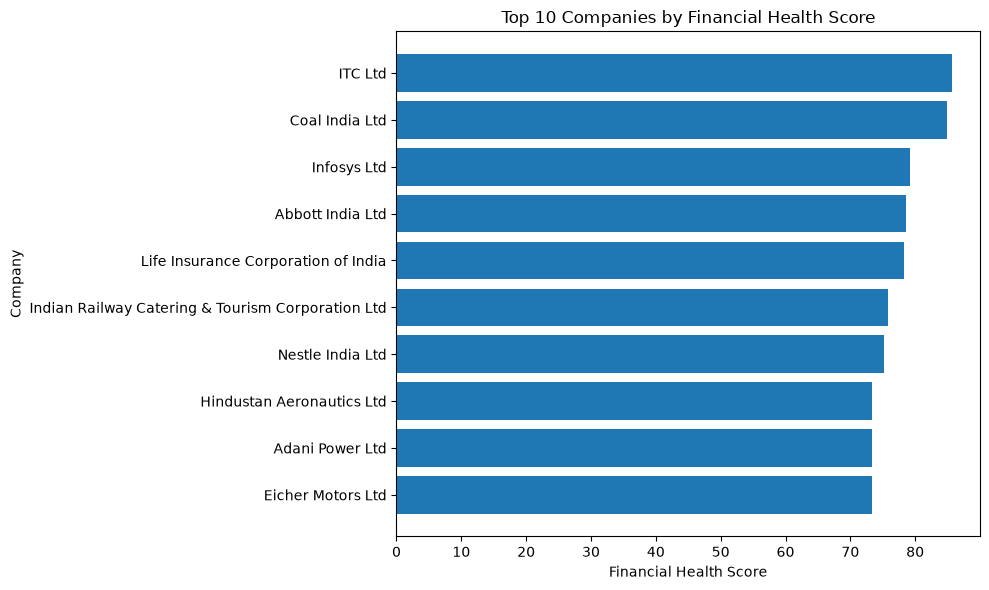


Top 10 financial health score chart completed


In [8]:
# ============================================================
# TOP 10 COMPANIES BY FINANCIAL HEALTH SCORE
# ============================================================

print("=" * 70)
print("TOP 10 COMPANIES BY FINANCIAL HEALTH SCORE")
print("=" * 70)

ranking_score_column = "financial_health_score"

top_10_financial = (
    rankings_df
    .dropna(subset=[ranking_score_column])
    .sort_values(
        by=ranking_score_column,
        ascending=False
    )
    .head(10)
)

print("\nTop 10 companies:")

display_columns = [
    "company_id",
    "company_name",
    "financial_health_score",
    "financial_rating"
]

display(
    top_10_financial[
        display_columns
    ]
)

# Sort ascending only for horizontal chart display
top_10_chart = top_10_financial.sort_values(
    by=ranking_score_column,
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_chart["company_name"],
    top_10_chart[ranking_score_column]
)

plt.title(
    "Top 10 Companies by Financial Health Score"
)

plt.xlabel("Financial Health Score")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

print(
    "\nTop 10 financial health score chart completed"
)

ROE VS ROCE PROFITABILITY ANALYSIS

Companies available for profitability analysis: 90

ROE and ROCE summary:


,roe_percentage,roce_percentage
count,90.000000,90.000000
mean,20.212444,22.436556
std,17.253050,23.626402
min,0.520000,1.630000
25%,11.675000,9.970000
50%,16.700000,15.650000
75%,22.650000,26.860000
max,135.610000,185.430000


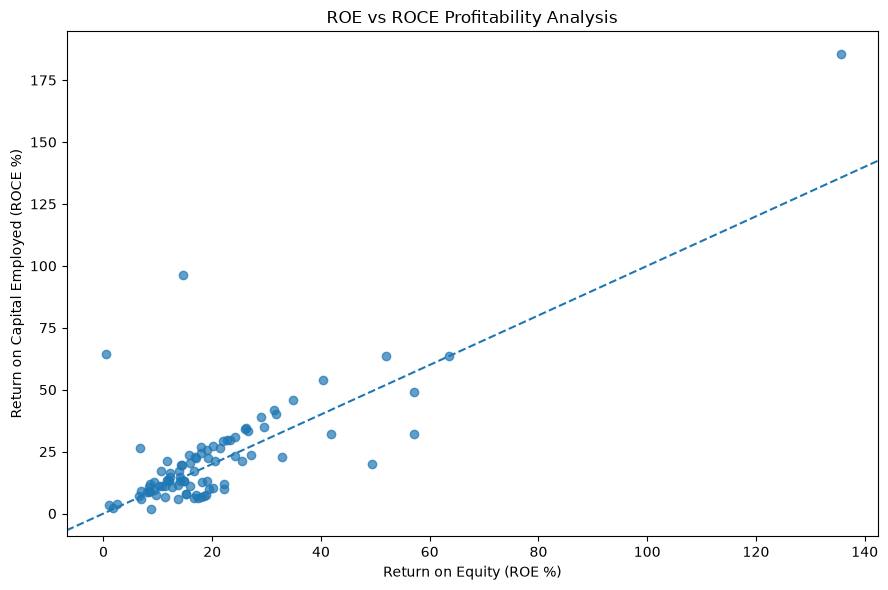


Top 10 companies by ROE:


,company_id,company_name,roe_percentage,roce_percentage
6,NESTLEIND,Nestle India Ltd,135.61,185.43
4,LICI,Life Insurance Corporation of India,63.61,63.79
8,ADANIPOWER,Adani Power Ltd,57.10,32.20
26,BRITANNIA,Britannia Industries Ltd,57.10,48.90
1,COALINDIA,Coal India Ltd,52.00,63.60
24,TATAMOTORS,Tata Motors Ltd,49.40,20.10
22,BPCL,Bharat Petroleum Corporation Ltd,41.90,32.10
5,IRCTC,Indian Railway Catering & Tourism Corporation Ltd,40.40,53.80
3,ABB,Abbott India Ltd,34.90,46.00
57,TITAN,Titan Company Ltd,32.90,22.70



ROE vs ROCE profitability analysis completed


In [9]:
# ============================================================
# ROE VS ROCE PROFITABILITY ANALYSIS
# ============================================================

print("=" * 70)
print("ROE VS ROCE PROFITABILITY ANALYSIS")
print("=" * 70)

profitability_df = metrics_df[
    [
        "company_id",
        "company_name",
        "roe_percentage",
        "roce_percentage"
    ]
].copy()

profitability_df = profitability_df.dropna(
    subset=[
        "roe_percentage",
        "roce_percentage"
    ]
)

print(
    f"\nCompanies available for profitability analysis: "
    f"{len(profitability_df)}"
)

print("\nROE and ROCE summary:")

display(
    profitability_df[
        [
            "roe_percentage",
            "roce_percentage"
        ]
    ].describe()
)

plt.figure(figsize=(9, 6))

plt.scatter(
    profitability_df["roe_percentage"],
    profitability_df["roce_percentage"],
    alpha=0.7
)

plt.title("ROE vs ROCE Profitability Analysis")
plt.xlabel("Return on Equity (ROE %)")
plt.ylabel("Return on Capital Employed (ROCE %)")

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--"
)

plt.tight_layout()
plt.show()

print("\nTop 10 companies by ROE:")

top_10_roe = (
    profitability_df
    .sort_values(
        by="roe_percentage",
        ascending=False
    )
    .head(10)
)

display(
    top_10_roe[
        [
            "company_id",
            "company_name",
            "roe_percentage",
            "roce_percentage"
        ]
    ]
)

print("\nROE vs ROCE profitability analysis completed")

PROFIT MARGIN ANALYSIS

Companies available for margin analysis: 91

Profit margin summary:


,operating_margin_percentage,net_profit_margin_percentage
count,91.000000,91.000000
mean,34.381939,19.975674
std,27.238449,45.327758
min,-12.603673,-3.200961
25%,14.874658,7.057148
50%,26.456547,13.841691
75%,40.625349,21.248893
max,99.586191,431.967686


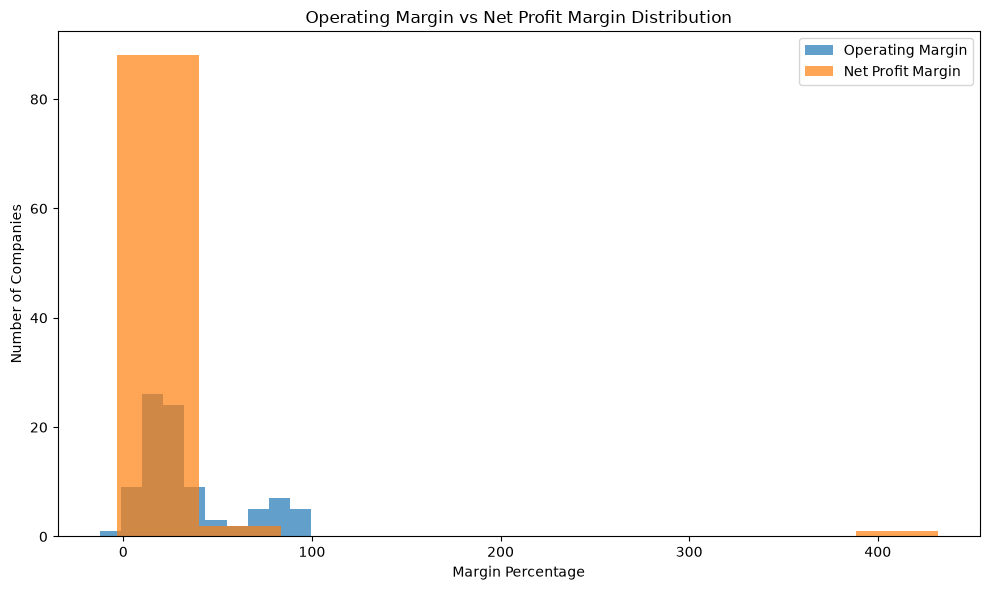


Top 10 companies by net profit margin:


,company_id,company_name,operating_margin_percentage,net_profit_margin_percentage
28,BAJAJHLDNG,Bajaj Holdings & Investment Ltd,89.671091,431.967686
54,JIOFIN,Jio Financial Services Ltd,77.794715,81.656504
59,DLF,DLF Ltd,26.924725,57.191830
52,NHPC,NHPC Ltd,51.754386,35.263158
45,KOTAKBANK,Kotak Mahindra Bank Ltd,79.421729,35.173997
23,POWERGRID,Power Grid Corporation of India Ltd,85.643500,34.296691
30,ADANIPORTS,Adani Ports & Special Economic Zone Ltd,60.348768,34.254474
35,ICICIBANK,ICICI Bank Ltd,69.632403,29.031132
63,RECLTD,REC Ltd,98.776461,28.908526
70,PFC,Power Finance Corporation Ltd,36.437362,28.779852


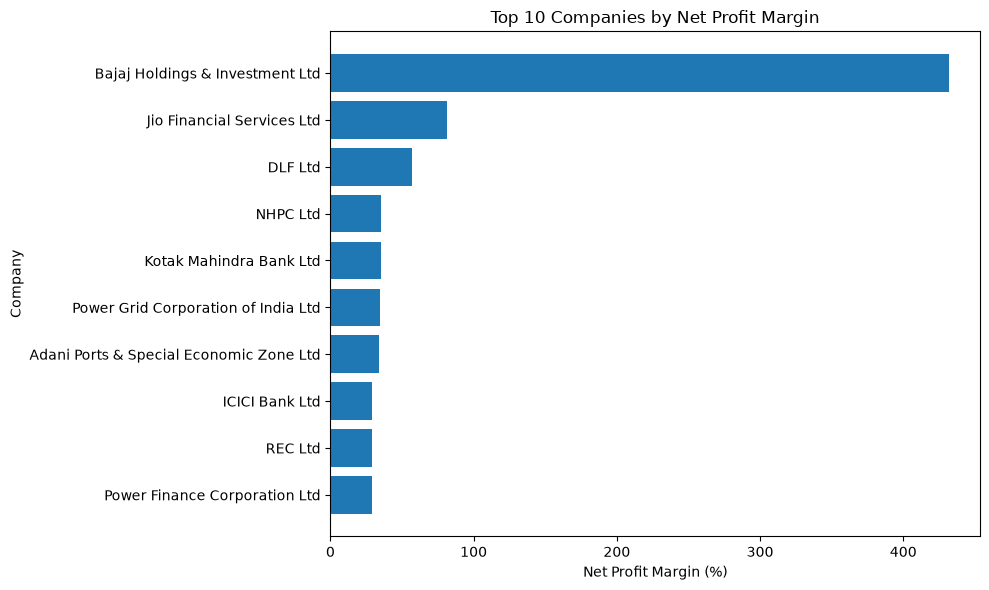


Profit margin analysis completed


In [10]:
# ============================================================
# PROFIT MARGIN ANALYSIS
# ============================================================

print("=" * 70)
print("PROFIT MARGIN ANALYSIS")
print("=" * 70)

margin_df = metrics_df[
    [
        "company_id",
        "company_name",
        "operating_margin_percentage",
        "net_profit_margin_percentage"
    ]
].copy()

margin_df = margin_df.dropna(
    subset=[
        "operating_margin_percentage",
        "net_profit_margin_percentage"
    ]
)

print(
    f"\nCompanies available for margin analysis: "
    f"{len(margin_df)}"
)

print("\nProfit margin summary:")

display(
    margin_df[
        [
            "operating_margin_percentage",
            "net_profit_margin_percentage"
        ]
    ].describe()
)

# ------------------------------------------------------------
# PROFIT MARGIN DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    margin_df["operating_margin_percentage"],
    bins=10,
    alpha=0.7,
    label="Operating Margin"
)

plt.hist(
    margin_df["net_profit_margin_percentage"],
    bins=10,
    alpha=0.7,
    label="Net Profit Margin"
)

plt.title("Operating Margin vs Net Profit Margin Distribution")
plt.xlabel("Margin Percentage")
plt.ylabel("Number of Companies")
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# TOP 10 COMPANIES BY NET PROFIT MARGIN
# ------------------------------------------------------------

top_10_margin = (
    margin_df
    .sort_values(
        by="net_profit_margin_percentage",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 companies by net profit margin:")

display(
    top_10_margin[
        [
            "company_id",
            "company_name",
            "operating_margin_percentage",
            "net_profit_margin_percentage"
        ]
    ]
)

# ------------------------------------------------------------
# TOP 10 NET PROFIT MARGIN CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_margin["company_name"][::-1],
    top_10_margin["net_profit_margin_percentage"][::-1]
)

plt.title("Top 10 Companies by Net Profit Margin")
plt.xlabel("Net Profit Margin (%)")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

print("\nProfit margin analysis completed")

SALES AND PROFIT GROWTH ANALYSIS

Companies available for growth analysis: 0

Sales and profit growth summary:


,compounded_sales_growth,compounded_profit_growth
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


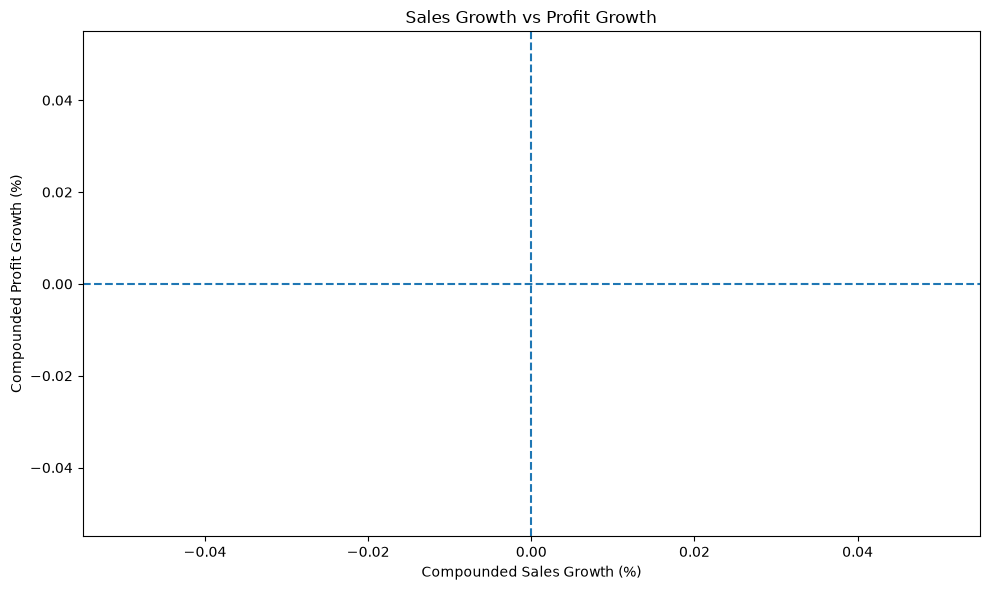


Top 10 companies by compounded sales growth:


,company_id,company_name,compounded_sales_growth,compounded_profit_growth


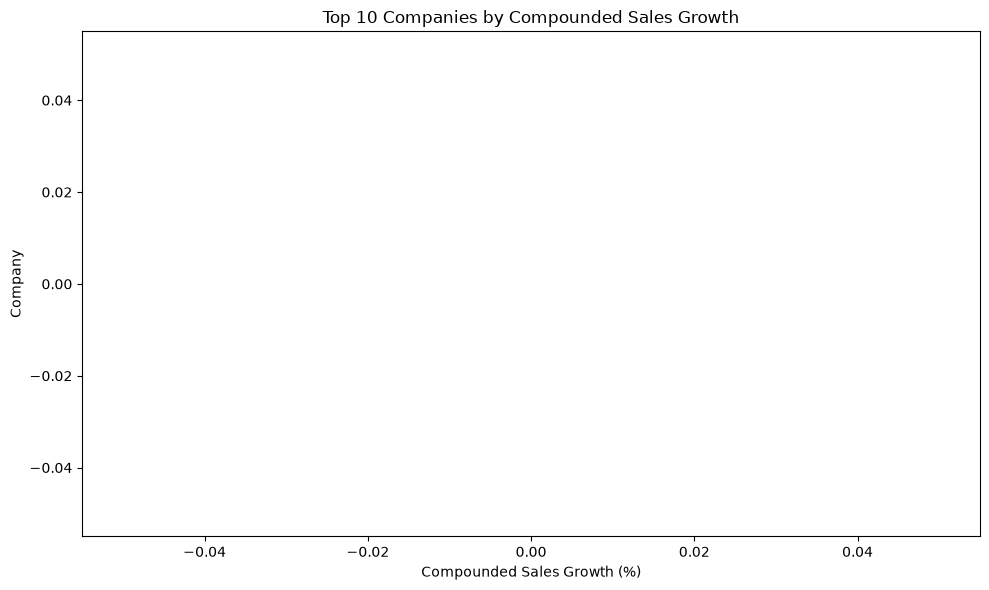


Top 10 companies by compounded profit growth:


,company_id,company_name,compounded_sales_growth,compounded_profit_growth


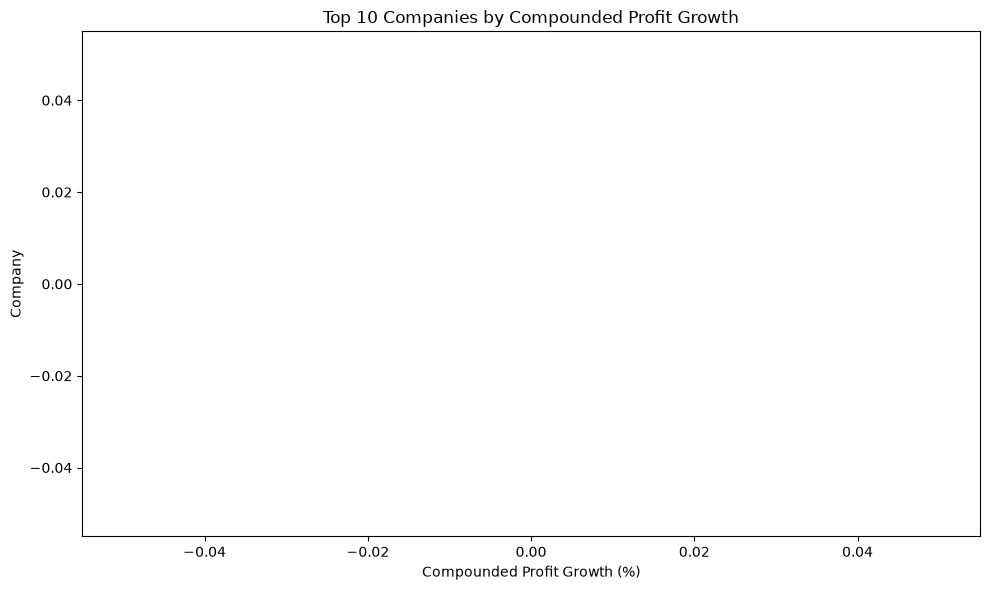


Sales and profit growth analysis completed


In [11]:
# ============================================================
# SALES AND PROFIT GROWTH ANALYSIS
# ============================================================

print("=" * 70)
print("SALES AND PROFIT GROWTH ANALYSIS")
print("=" * 70)

growth_df = metrics_df[
    [
        "company_id",
        "company_name",
        "compounded_sales_growth",
        "compounded_profit_growth"
    ]
].copy()

growth_df = growth_df.dropna(
    subset=[
        "compounded_sales_growth",
        "compounded_profit_growth"
    ]
)

print(
    f"\nCompanies available for growth analysis: "
    f"{len(growth_df)}"
)

# ------------------------------------------------------------
# GROWTH SUMMARY
# ------------------------------------------------------------

print("\nSales and profit growth summary:")

display(
    growth_df[
        [
            "compounded_sales_growth",
            "compounded_profit_growth"
        ]
    ].describe()
)

# ------------------------------------------------------------
# SALES GROWTH VS PROFIT GROWTH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    growth_df["compounded_sales_growth"],
    growth_df["compounded_profit_growth"],
    alpha=0.7
)

plt.title("Sales Growth vs Profit Growth")
plt.xlabel("Compounded Sales Growth (%)")
plt.ylabel("Compounded Profit Growth (%)")

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# TOP 10 COMPANIES BY SALES GROWTH
# ------------------------------------------------------------

top_10_sales_growth = (
    growth_df
    .sort_values(
        by="compounded_sales_growth",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 companies by compounded sales growth:")

display(
    top_10_sales_growth[
        [
            "company_id",
            "company_name",
            "compounded_sales_growth",
            "compounded_profit_growth"
        ]
    ]
)

# ------------------------------------------------------------
# TOP 10 SALES GROWTH CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_sales_growth["company_name"][::-1],
    top_10_sales_growth["compounded_sales_growth"][::-1]
)

plt.title("Top 10 Companies by Compounded Sales Growth")
plt.xlabel("Compounded Sales Growth (%)")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# TOP 10 COMPANIES BY PROFIT GROWTH
# ------------------------------------------------------------

top_10_profit_growth = (
    growth_df
    .sort_values(
        by="compounded_profit_growth",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 companies by compounded profit growth:")

display(
    top_10_profit_growth[
        [
            "company_id",
            "company_name",
            "compounded_sales_growth",
            "compounded_profit_growth"
        ]
    ]
)

# ------------------------------------------------------------
# TOP 10 PROFIT GROWTH CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_profit_growth["company_name"][::-1],
    top_10_profit_growth["compounded_profit_growth"][::-1]
)

plt.title("Top 10 Companies by Compounded Profit Growth")
plt.xlabel("Compounded Profit Growth (%)")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

print("\nSales and profit growth analysis completed")

STOCK CAGR ANALYSIS

Companies available for stock CAGR analysis: 0

Stock CAGR summary:


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: stock_price_cagr, dtype: float64

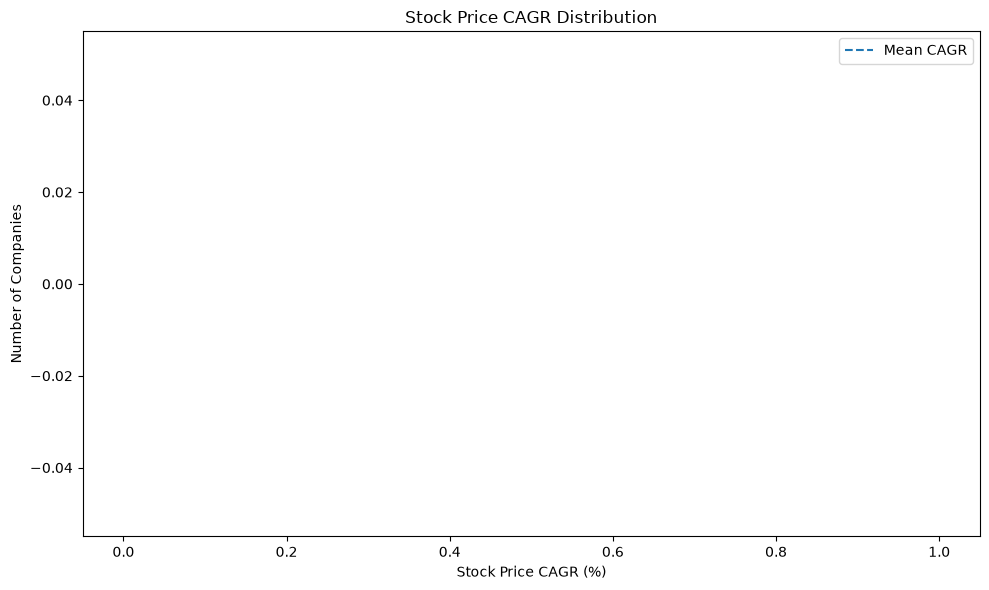


Top 10 companies by stock price CAGR:


,company_id,company_name,stock_price_cagr


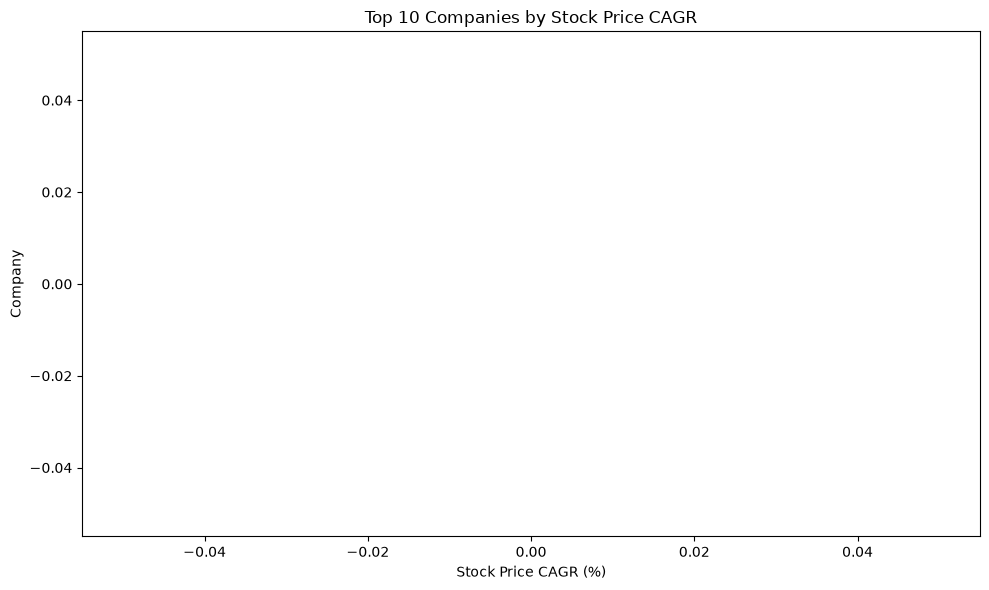


Stock CAGR classification:
Positive CAGR companies : 0
Negative CAGR companies : 0
Zero CAGR companies     : 0

Stock CAGR analysis completed


In [12]:
# ============================================================
# STOCK CAGR ANALYSIS
# ============================================================

print("=" * 70)
print("STOCK CAGR ANALYSIS")
print("=" * 70)

stock_df = metrics_df[
    [
        "company_id",
        "company_name",
        "stock_price_cagr"
    ]
].copy()

stock_df = stock_df.dropna(
    subset=["stock_price_cagr"]
)

print(
    f"\nCompanies available for stock CAGR analysis: "
    f"{len(stock_df)}"
)

# ------------------------------------------------------------
# STOCK CAGR SUMMARY
# ------------------------------------------------------------

print("\nStock CAGR summary:")

display(
    stock_df["stock_price_cagr"].describe()
)

# ------------------------------------------------------------
# STOCK CAGR DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    stock_df["stock_price_cagr"],
    bins=10
)

plt.title("Stock Price CAGR Distribution")
plt.xlabel("Stock Price CAGR (%)")
plt.ylabel("Number of Companies")

plt.axvline(
    stock_df["stock_price_cagr"].mean(),
    linestyle="--",
    label="Mean CAGR"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# TOP 10 COMPANIES BY STOCK CAGR
# ------------------------------------------------------------

top_10_stock_cagr = (
    stock_df
    .sort_values(
        by="stock_price_cagr",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 companies by stock price CAGR:")

display(
    top_10_stock_cagr[
        [
            "company_id",
            "company_name",
            "stock_price_cagr"
        ]
    ]
)

# ------------------------------------------------------------
# TOP 10 STOCK CAGR CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_stock_cagr["company_name"][::-1],
    top_10_stock_cagr["stock_price_cagr"][::-1]
)

plt.title("Top 10 Companies by Stock Price CAGR")
plt.xlabel("Stock Price CAGR (%)")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# POSITIVE AND NEGATIVE CAGR COMPANIES
# ------------------------------------------------------------

positive_cagr = (
    stock_df["stock_price_cagr"] > 0
).sum()

negative_cagr = (
    stock_df["stock_price_cagr"] < 0
).sum()

zero_cagr = (
    stock_df["stock_price_cagr"] == 0
).sum()

print("\nStock CAGR classification:")
print(f"Positive CAGR companies : {positive_cagr}")
print(f"Negative CAGR companies : {negative_cagr}")
print(f"Zero CAGR companies     : {zero_cagr}")

print("\nStock CAGR analysis completed")

DEBT AND CASH FLOW ANALYSIS

Companies available for debt and cash flow analysis: 92

Debt to asset ratio summary:


count    91.000000
mean      0.277893
std       0.281093
min       0.000000
25%       0.029451
50%       0.207317
75%       0.450090
max       0.892354
Name: debt_to_asset_ratio, dtype: float64

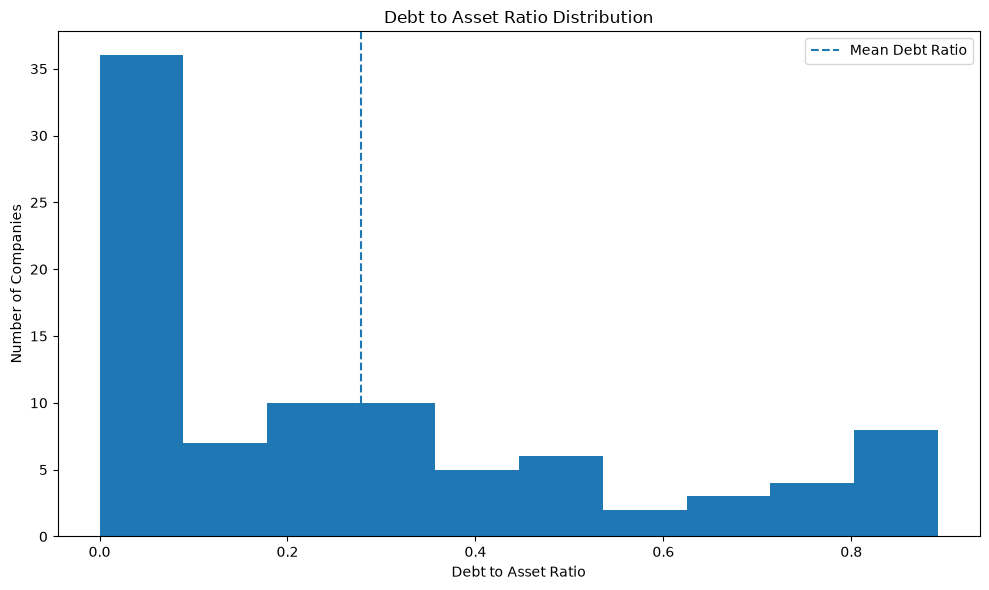


Top 10 companies by debt to asset ratio:


,company_id,company_name,debt_to_asset_ratio
67,CANBK,Canara Bank,0.892354
86,BANKBARODA,Bank of Baroda,0.878525
78,CHOLAFIN,Cholamandalam Investment & Finance Company Ltd,0.868081
77,AXISBANK,Axis Bank Ltd,0.853161
84,INDUSINDBK,IndusInd Bank Ltd,0.839725
70,PFC,Power Finance Corporation Ltd,0.825158
68,IRFC,Indian Railway Finance Corporation Ltd,0.815440
63,RECLTD,REC Ltd,0.812492
46,HDFCBANK,HDFC Bank Ltd,0.771055
61,BAJFINANCE,Bajaj Finance Ltd,0.770744



Companies available for cash flow comparison: 91


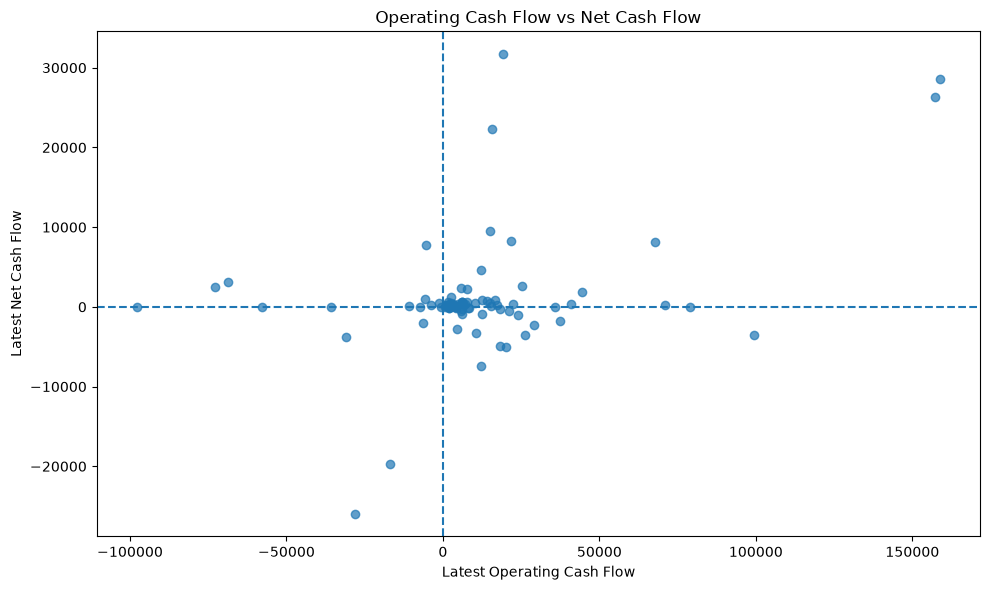


Top 10 companies by operating cash flow:


,company_id,company_name,latest_operating_cash_flow,latest_net_cash_flow
51,RELIANCE,Reliance Industries Ltd,158788.0,28561.0
35,ICICIBANK,ICICI Bank Ltd,157284.0,26312.0
43,ONGC,Oil & Natural Gas Corpn Ltd,99263.0,-3591.0
49,BHARTIARTL,Bharti Airtel Ltd,78898.0,31.0
36,IOC,Indian Oil Corporation,71099.0,250.0
24,TATAMOTORS,Tata Motors Ltd,67915.0,8128.0
14,TCS,Tata Consultancy Services Ltd,44338.0,1893.0
58,NTPC,NTPC Ltd,40785.0,398.0
23,POWERGRID,Power Grid Corporation of India Ltd,37290.0,-1728.0
22,BPCL,Bharat Petroleum Corporation Ltd,35936.0,-12.0


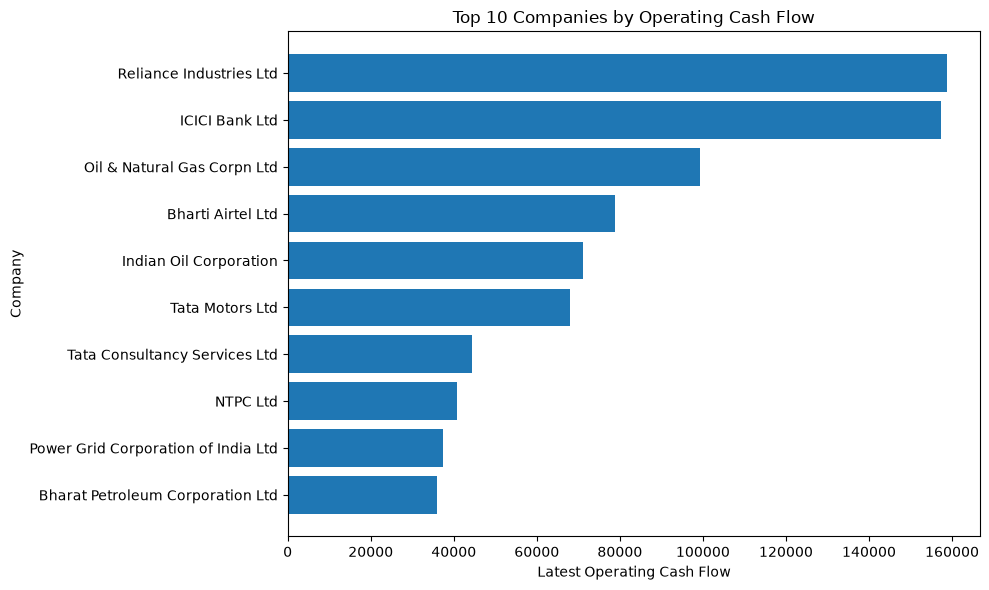


Operating cash flow classification:
Positive operating cash flow companies : 75
Negative operating cash flow companies : 16

Debt and cash flow analysis completed


In [13]:
# ============================================================
# DEBT AND CASH FLOW ANALYSIS
# ============================================================

print("=" * 70)
print("DEBT AND CASH FLOW ANALYSIS")
print("=" * 70)

debt_cash_df = metrics_df[
    [
        "company_id",
        "company_name",
        "debt_to_asset_ratio",
        "latest_operating_cash_flow",
        "latest_net_cash_flow"
    ]
].copy()

print(
    f"\nCompanies available for debt and cash flow analysis: "
    f"{len(debt_cash_df)}"
)

# ------------------------------------------------------------
# DEBT TO ASSET RATIO SUMMARY
# ------------------------------------------------------------

print("\nDebt to asset ratio summary:")

display(
    debt_cash_df["debt_to_asset_ratio"].describe()
)

# ------------------------------------------------------------
# DEBT TO ASSET RATIO DISTRIBUTION
# ------------------------------------------------------------

debt_data = debt_cash_df[
    "debt_to_asset_ratio"
].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    debt_data,
    bins=10
)

plt.title("Debt to Asset Ratio Distribution")
plt.xlabel("Debt to Asset Ratio")
plt.ylabel("Number of Companies")

plt.axvline(
    debt_data.mean(),
    linestyle="--",
    label="Mean Debt Ratio"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# TOP 10 COMPANIES BY DEBT TO ASSET RATIO
# ------------------------------------------------------------

top_10_debt = (
    debt_cash_df
    .dropna(subset=["debt_to_asset_ratio"])
    .sort_values(
        by="debt_to_asset_ratio",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 companies by debt to asset ratio:")

display(
    top_10_debt[
        [
            "company_id",
            "company_name",
            "debt_to_asset_ratio"
        ]
    ]
)

# ------------------------------------------------------------
# OPERATING CASH FLOW VS NET CASH FLOW
# ------------------------------------------------------------

cash_flow_df = debt_cash_df.dropna(
    subset=[
        "latest_operating_cash_flow",
        "latest_net_cash_flow"
    ]
)

print(
    f"\nCompanies available for cash flow comparison: "
    f"{len(cash_flow_df)}"
)

plt.figure(figsize=(10, 6))

plt.scatter(
    cash_flow_df["latest_operating_cash_flow"],
    cash_flow_df["latest_net_cash_flow"],
    alpha=0.7
)

plt.title("Operating Cash Flow vs Net Cash Flow")
plt.xlabel("Latest Operating Cash Flow")
plt.ylabel("Latest Net Cash Flow")

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# TOP 10 COMPANIES BY OPERATING CASH FLOW
# ------------------------------------------------------------

top_10_cash_flow = (
    debt_cash_df
    .dropna(subset=["latest_operating_cash_flow"])
    .sort_values(
        by="latest_operating_cash_flow",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 companies by operating cash flow:")

display(
    top_10_cash_flow[
        [
            "company_id",
            "company_name",
            "latest_operating_cash_flow",
            "latest_net_cash_flow"
        ]
    ]
)

# ------------------------------------------------------------
# TOP 10 OPERATING CASH FLOW CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_cash_flow["company_name"][::-1],
    top_10_cash_flow["latest_operating_cash_flow"][::-1]
)

plt.title("Top 10 Companies by Operating Cash Flow")
plt.xlabel("Latest Operating Cash Flow")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CASH FLOW CLASSIFICATION
# ------------------------------------------------------------

positive_operating_cash_flow = (
    debt_cash_df["latest_operating_cash_flow"] > 0
).sum()

negative_operating_cash_flow = (
    debt_cash_df["latest_operating_cash_flow"] < 0
).sum()

print("\nOperating cash flow classification:")
print(
    f"Positive operating cash flow companies : "
    f"{positive_operating_cash_flow}"
)
print(
    f"Negative operating cash flow companies : "
    f"{negative_operating_cash_flow}"
)

print("\nDebt and cash flow analysis completed")

FINANCIAL RATING ANALYSIS

Companies available for financial rating analysis: 92

Financial health score summary:


count    92.000000
mean     50.259348
std      16.362959
min      16.260000
25%      38.065000
50%      48.545000
75%      63.072500
max      85.710000
Name: financial_health_score, dtype: float64


Financial rating distribution:


,company_count
financial_rating,
AVERAGE,30
GOOD,28
WEAK,17
STRONG,15
EXCELLENT,2


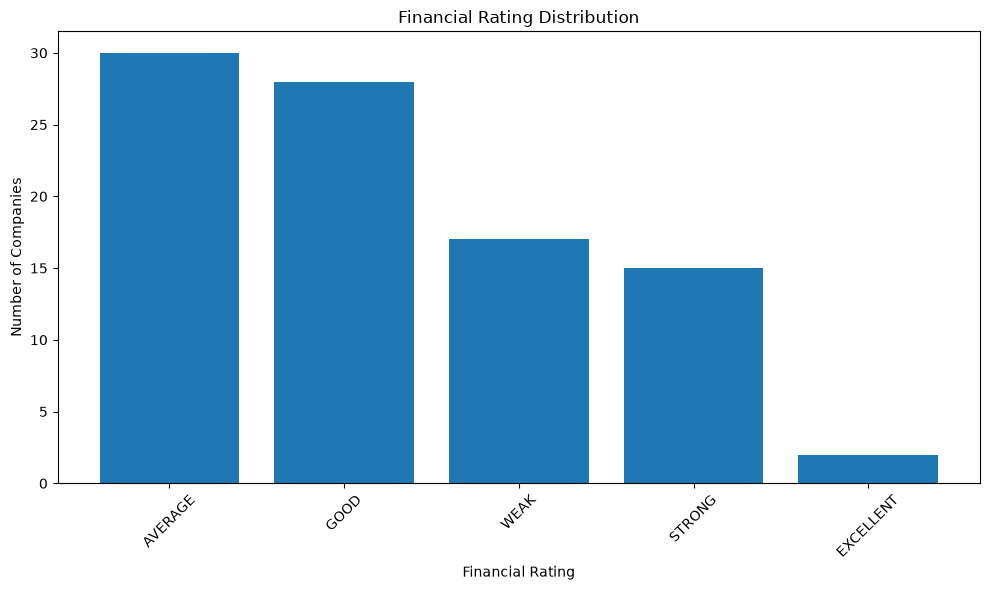

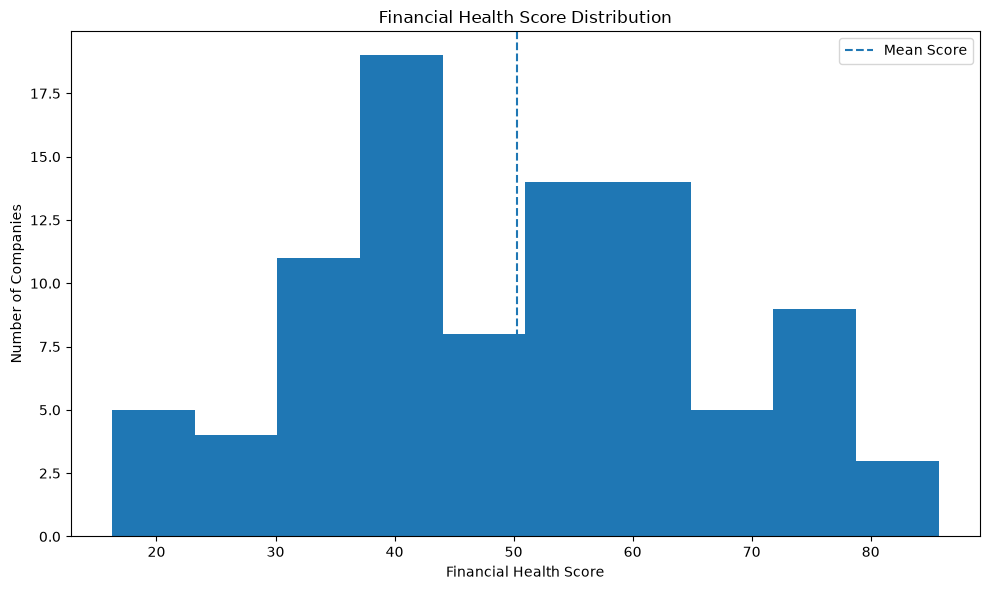


Top 10 companies by financial health score:


,company_id,company_name,financial_health_score,financial_rating
0,ITC,ITC Ltd,85.71,EXCELLENT
1,COALINDIA,Coal India Ltd,84.86,EXCELLENT
2,INFY,Infosys Ltd,79.17,STRONG
3,ABB,Abbott India Ltd,78.61,STRONG
4,LICI,Life Insurance Corporation of India,78.21,STRONG
5,IRCTC,Indian Railway Catering & Tourism Corporation Ltd,75.84,STRONG
6,NESTLEIND,Nestle India Ltd,75.25,STRONG
7,HAL,Hindustan Aeronautics Ltd,73.40,STRONG
8,ADANIPOWER,Adani Power Ltd,73.33,STRONG
9,EICHERMOT,Eicher Motors Ltd,73.28,STRONG


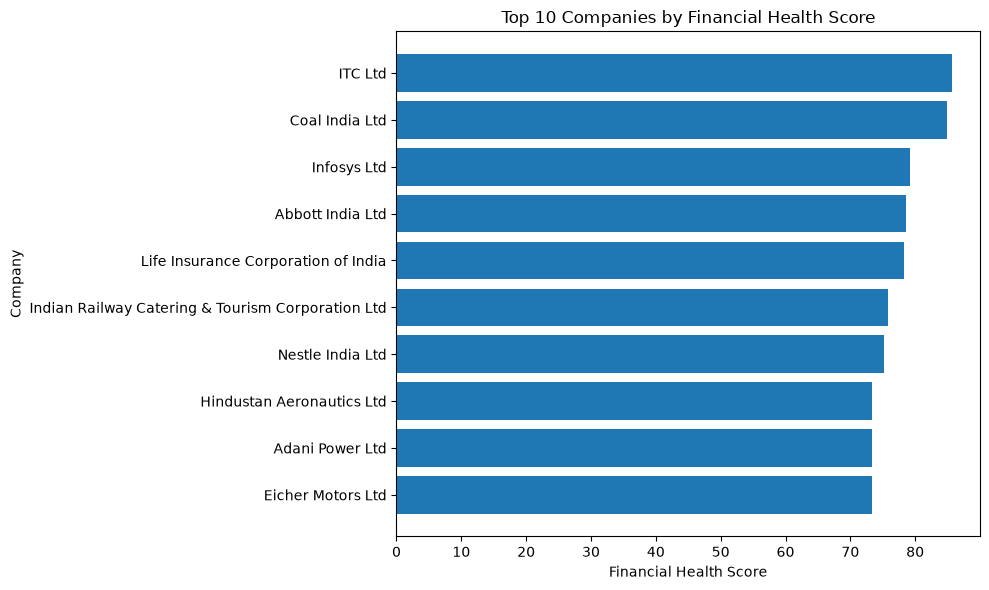


Financial rating percentage distribution:


,percentage
financial_rating,
AVERAGE,32.61
GOOD,30.43
WEAK,18.48
STRONG,16.30
EXCELLENT,2.17



Financial rating analysis completed


In [14]:
# ============================================================
# FINANCIAL RATING ANALYSIS
# ============================================================

print("=" * 70)
print("FINANCIAL RATING ANALYSIS")
print("=" * 70)

rating_df = metrics_df[
    [
        "company_id",
        "company_name",
        "financial_health_score",
        "financial_rating"
    ]
].copy()

print(
    f"\nCompanies available for financial rating analysis: "
    f"{len(rating_df)}"
)

# ------------------------------------------------------------
# FINANCIAL HEALTH SCORE SUMMARY
# ------------------------------------------------------------

print("\nFinancial health score summary:")

display(
    rating_df["financial_health_score"].describe()
)

# ------------------------------------------------------------
# FINANCIAL RATING DISTRIBUTION
# ------------------------------------------------------------

rating_counts = (
    rating_df["financial_rating"]
    .fillna("UNKNOWN")
    .value_counts()
)

print("\nFinancial rating distribution:")

display(
    rating_counts.to_frame(name="company_count")
)

# ------------------------------------------------------------
# FINANCIAL RATING BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title("Financial Rating Distribution")
plt.xlabel("Financial Rating")
plt.ylabel("Number of Companies")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# FINANCIAL HEALTH SCORE DISTRIBUTION
# ------------------------------------------------------------

health_score_data = rating_df[
    "financial_health_score"
].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    health_score_data,
    bins=10
)

plt.title("Financial Health Score Distribution")
plt.xlabel("Financial Health Score")
plt.ylabel("Number of Companies")

plt.axvline(
    health_score_data.mean(),
    linestyle="--",
    label="Mean Score"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# TOP 10 COMPANIES BY FINANCIAL HEALTH SCORE
# ------------------------------------------------------------

top_10_health = (
    rating_df
    .dropna(subset=["financial_health_score"])
    .sort_values(
        by="financial_health_score",
        ascending=False
    )
    .head(10)
)

print("\nTop 10 companies by financial health score:")

display(
    top_10_health[
        [
            "company_id",
            "company_name",
            "financial_health_score",
            "financial_rating"
        ]
    ]
)

# ------------------------------------------------------------
# TOP 10 FINANCIAL HEALTH SCORE CHART
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_health["company_name"][::-1],
    top_10_health["financial_health_score"][::-1]
)

plt.title("Top 10 Companies by Financial Health Score")
plt.xlabel("Financial Health Score")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# RATING PERCENTAGE DISTRIBUTION
# ------------------------------------------------------------

rating_percentage = (
    rating_counts / rating_counts.sum() * 100
).round(2)

print("\nFinancial rating percentage distribution:")

display(
    rating_percentage.to_frame(
        name="percentage"
    )
)

print("\nFinancial rating analysis completed")

In [15]:
# ============================================================
# KEY FINANCIAL INTELLIGENCE INSIGHTS
# ============================================================

print("=" * 70)
print("KEY FINANCIAL INTELLIGENCE INSIGHTS")
print("=" * 70)

insights = []

# ------------------------------------------------------------
# INSIGHT 1: TOP FINANCIAL HEALTH COMPANY
# ------------------------------------------------------------

valid_health = metrics_df.dropna(
    subset=["financial_health_score"]
)

if not valid_health.empty:
    top_health_company = valid_health.sort_values(
        by="financial_health_score",
        ascending=False
    ).iloc[0]

    insight = (
        f"1. {top_health_company['company_name']} has the highest "
        f"financial health score of "
        f"{top_health_company['financial_health_score']:.2f}."
    )

    insights.append(insight)


# ------------------------------------------------------------
# INSIGHT 2: HIGHEST ROE COMPANY
# ------------------------------------------------------------

valid_roe = metrics_df.dropna(
    subset=["roe_percentage"]
)

if not valid_roe.empty:
    top_roe_company = valid_roe.sort_values(
        by="roe_percentage",
        ascending=False
    ).iloc[0]

    insight = (
        f"2. {top_roe_company['company_name']} records the highest "
        f"ROE of {top_roe_company['roe_percentage']:.2f}%."
    )

    insights.append(insight)


# ------------------------------------------------------------
# INSIGHT 3: HIGHEST ROCE COMPANY
# ------------------------------------------------------------

valid_roce = metrics_df.dropna(
    subset=["roce_percentage"]
)

if not valid_roce.empty:
    top_roce_company = valid_roce.sort_values(
        by="roce_percentage",
        ascending=False
    ).iloc[0]

    insight = (
        f"3. {top_roce_company['company_name']} records the highest "
        f"ROCE of {top_roce_company['roce_percentage']:.2f}%."
    )

    insights.append(insight)


# ------------------------------------------------------------
# INSIGHT 4: HIGHEST NET PROFIT MARGIN
# ------------------------------------------------------------

valid_margin = metrics_df.dropna(
    subset=["net_profit_margin_percentage"]
)

if not valid_margin.empty:
    top_margin_company = valid_margin.sort_values(
        by="net_profit_margin_percentage",
        ascending=False
    ).iloc[0]

    insight = (
        f"4. {top_margin_company['company_name']} has the highest "
        f"net profit margin of "
        f"{top_margin_company['net_profit_margin_percentage']:.2f}%."
    )

    insights.append(insight)


# ------------------------------------------------------------
# INSIGHT 5: HIGHEST SALES GROWTH
# ------------------------------------------------------------

valid_sales_growth = metrics_df.dropna(
    subset=["compounded_sales_growth"]
)

if not valid_sales_growth.empty:
    top_sales_growth = valid_sales_growth.sort_values(
        by="compounded_sales_growth",
        ascending=False
    ).iloc[0]

    insight = (
        f"5. {top_sales_growth['company_name']} leads compounded "
        f"sales growth at "
        f"{top_sales_growth['compounded_sales_growth']:.2f}%."
    )

    insights.append(insight)
else:
    insights.append(
        "5. Compounded sales growth data is unavailable "
        "for the current company metrics dataset."
    )


# ------------------------------------------------------------
# INSIGHT 6: HIGHEST PROFIT GROWTH
# ------------------------------------------------------------

valid_profit_growth = metrics_df.dropna(
    subset=["compounded_profit_growth"]
)

if not valid_profit_growth.empty:
    top_profit_growth = valid_profit_growth.sort_values(
        by="compounded_profit_growth",
        ascending=False
    ).iloc[0]

    insight = (
        f"6. {top_profit_growth['company_name']} leads compounded "
        f"profit growth at "
        f"{top_profit_growth['compounded_profit_growth']:.2f}%."
    )

    insights.append(insight)
else:
    insights.append(
        "6. Compounded profit growth data is unavailable "
        "for the current company metrics dataset."
    )


# ------------------------------------------------------------
# INSIGHT 7: HIGHEST STOCK CAGR
# ------------------------------------------------------------

valid_stock_cagr = metrics_df.dropna(
    subset=["stock_price_cagr"]
)

if not valid_stock_cagr.empty:
    top_stock_cagr = valid_stock_cagr.sort_values(
        by="stock_price_cagr",
        ascending=False
    ).iloc[0]

    insight = (
        f"7. {top_stock_cagr['company_name']} has the highest "
        f"stock price CAGR at "
        f"{top_stock_cagr['stock_price_cagr']:.2f}%."
    )

    insights.append(insight)
else:
    insights.append(
        "7. Stock price CAGR data is unavailable "
        "for the current company metrics dataset."
    )


# ------------------------------------------------------------
# INSIGHT 8: HIGHEST OPERATING CASH FLOW
# ------------------------------------------------------------

valid_cash_flow = metrics_df.dropna(
    subset=["latest_operating_cash_flow"]
)

if not valid_cash_flow.empty:
    top_cash_flow = valid_cash_flow.sort_values(
        by="latest_operating_cash_flow",
        ascending=False
    ).iloc[0]

    insight = (
        f"8. {top_cash_flow['company_name']} reports the highest "
        f"latest operating cash flow of "
        f"{top_cash_flow['latest_operating_cash_flow']:.2f}."
    )

    insights.append(insight)


# ------------------------------------------------------------
# INSIGHT 9: FINANCIAL RATING DISTRIBUTION
# ------------------------------------------------------------

valid_ratings = metrics_df[
    "financial_rating"
].dropna()

if not valid_ratings.empty:
    most_common_rating = (
        valid_ratings
        .value_counts()
        .idxmax()
    )

    rating_count = (
        valid_ratings
        .value_counts()
        .max()
    )

    insight = (
        f"9. The most common financial rating is "
        f"{most_common_rating}, assigned to "
        f"{rating_count} companies."
    )

    insights.append(insight)


# ------------------------------------------------------------
# INSIGHT 10: POSITIVE OPERATING CASH FLOW
# ------------------------------------------------------------

cash_flow_values = pd.to_numeric(
    metrics_df["latest_operating_cash_flow"],
    errors="coerce"
)

positive_cash_flow_count = (
    cash_flow_values > 0
).sum()

cash_flow_company_count = (
    cash_flow_values.notna()
).sum()

if cash_flow_company_count > 0:
    positive_cash_flow_percentage = (
        positive_cash_flow_count
        / cash_flow_company_count
        * 100
    )

    insight = (
        f"10. {positive_cash_flow_count} of "
        f"{cash_flow_company_count} companies with available cash-flow "
        f"data report positive operating cash flow "
        f"({positive_cash_flow_percentage:.2f}%)."
    )

    insights.append(insight)


# ------------------------------------------------------------
# DISPLAY KEY INSIGHTS
# ------------------------------------------------------------

print("\nTOP 10 FINANCIAL INTELLIGENCE INSIGHTS")
print("-" * 70)

for insight in insights:
    print()
    print(insight)


# ------------------------------------------------------------
# SAVE INSIGHTS
# ------------------------------------------------------------

INSIGHTS_FILE = (
    PROJECT_ROOT
    / "output"
    / "financial_intelligence_insights.txt"
)

INSIGHTS_FILE.write_text(
    "\n\n".join(insights),
    encoding="utf-8"
)

print("\n" + "-" * 70)

print(
    f"Financial intelligence insights saved to: "
    f"{INSIGHTS_FILE}"
)

print("\nKey financial intelligence insights completed")

KEY FINANCIAL INTELLIGENCE INSIGHTS

TOP 10 FINANCIAL INTELLIGENCE INSIGHTS
----------------------------------------------------------------------

1. ITC Ltd has the highest financial health score of 85.71.

2. Nestle India Ltd records the highest ROE of 135.61%.

3. Nestle India Ltd records the highest ROCE of 185.43%.

4. Bajaj Holdings & Investment Ltd has the highest net profit margin of 431.97%.

5. Compounded sales growth data is unavailable for the current company metrics dataset.

6. Compounded profit growth data is unavailable for the current company metrics dataset.

7. Stock price CAGR data is unavailable for the current company metrics dataset.

8. Reliance Industries Ltd reports the highest latest operating cash flow of 158788.00.

9. The most common financial rating is AVERAGE, assigned to 30 companies.

10. 75 of 91 companies with available cash-flow data report positive operating cash flow (82.42%).

---------------------------------------------------------------------

In [16]:
# ============================================================
# DAY 7 FINAL ANALYSIS SUMMARY
# ============================================================

print("=" * 70)
print("NIFTY 100 FINANCIAL INTELLIGENCE")
print("DAY 7 - EXPLORATORY FINANCIAL ANALYSIS SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# DATASET SUMMARY
# ------------------------------------------------------------

total_companies = len(metrics_df)

total_metric_columns = len(metrics_df.columns)

total_ranking_records = len(rankings_df)

print("\nDATASET SUMMARY")
print("-" * 70)

print(f"Companies Analysed      : {total_companies}")
print(f"Financial Metric Columns: {total_metric_columns}")
print(f"Company Ranking Records : {total_ranking_records}")


# ------------------------------------------------------------
# FINANCIAL HEALTH SUMMARY
# ------------------------------------------------------------

health_scores = pd.to_numeric(
    metrics_df["financial_health_score"],
    errors="coerce"
)

print("\nFINANCIAL HEALTH SUMMARY")
print("-" * 70)

print(
    f"Average Financial Health Score : "
    f"{health_scores.mean():.2f}"
)

print(
    f"Highest Financial Health Score : "
    f"{health_scores.max():.2f}"
)

print(
    f"Lowest Financial Health Score  : "
    f"{health_scores.min():.2f}"
)


# ------------------------------------------------------------
# FINANCIAL RATING SUMMARY
# ------------------------------------------------------------

rating_summary = (
    metrics_df["financial_rating"]
    .fillna("UNKNOWN")
    .value_counts()
)

print("\nFINANCIAL RATING SUMMARY")
print("-" * 70)

for rating, count in rating_summary.items():
    print(
        f"{str(rating):<15}: {count} companies"
    )


# ------------------------------------------------------------
# TOP RANKED COMPANY
# ------------------------------------------------------------

valid_rankings = rankings_df.dropna(
    subset=["financial_health_score"]
)

if not valid_rankings.empty:

    top_company = (
        valid_rankings
        .sort_values(
            by="financial_health_score",
            ascending=False
        )
        .iloc[0]
    )

    print("\nTOP RANKED COMPANY")
    print("-" * 70)

    print(
        f"Company : {top_company['company_name']}"
    )

    print(
        f"Score   : "
        f"{top_company['financial_health_score']:.2f}"
    )

    print(
        f"Rating  : "
        f"{top_company['financial_rating']}"
    )


# ------------------------------------------------------------
# DATA AVAILABILITY SUMMARY
# ------------------------------------------------------------

analysis_columns = [
    "roe_percentage",
    "roce_percentage",
    "net_profit_margin_percentage",
    "debt_to_asset_ratio",
    "latest_operating_cash_flow",
    "compounded_sales_growth",
    "compounded_profit_growth",
    "stock_price_cagr"
]

print("\nDATA AVAILABILITY SUMMARY")
print("-" * 70)

availability_results = []

for column in analysis_columns:

    if column not in metrics_df.columns:
        continue

    available_records = (
        metrics_df[column]
        .notna()
        .sum()
    )

    availability_percentage = (
        available_records
        / total_companies
        * 100
    )

    availability_results.append(
        {
            "metric": column,
            "available_records": available_records,
            "availability_percentage": round(
                availability_percentage,
                2
            )
        }
    )

    print(
        f"{column:<35} "
        f"{available_records:>3}/{total_companies} "
        f"({availability_percentage:>6.2f}%)"
    )


# ------------------------------------------------------------
# SAVE DAY 7 SUMMARY
# ------------------------------------------------------------

SUMMARY_FILE = (
    PROJECT_ROOT
    / "output"
    / "day7_analysis_summary.txt"
)

summary_lines = [
    "NIFTY 100 FINANCIAL INTELLIGENCE",
    "DAY 7 - EXPLORATORY FINANCIAL ANALYSIS SUMMARY",
    "=" * 70,
    "",
    f"Companies Analysed: {total_companies}",
    (
        "Financial Metric Columns: "
        f"{total_metric_columns}"
    ),
    (
        "Company Ranking Records: "
        f"{total_ranking_records}"
    ),
    "",
    (
        "Average Financial Health Score: "
        f"{health_scores.mean():.2f}"
    ),
    (
        "Highest Financial Health Score: "
        f"{health_scores.max():.2f}"
    ),
    (
        "Lowest Financial Health Score: "
        f"{health_scores.min():.2f}"
    ),
]

if not valid_rankings.empty:

    summary_lines.extend(
        [
            "",
            "TOP RANKED COMPANY",
            "-" * 70,
            (
                "Company: "
                f"{top_company['company_name']}"
            ),
            (
                "Financial Health Score: "
                f"{top_company['financial_health_score']:.2f}"
            ),
            (
                "Financial Rating: "
                f"{top_company['financial_rating']}"
            ),
        ]
    )

summary_lines.extend(
    [
        "",
        "DATA AVAILABILITY",
        "-" * 70,
    ]
)

for result in availability_results:

    summary_lines.append(
        f"{result['metric']}: "
        f"{result['available_records']}/"
        f"{total_companies} "
        f"({result['availability_percentage']:.2f}%)"
    )

summary_lines.extend(
    [
        "",
        "=" * 70,
        "DAY 7 EXPLORATORY FINANCIAL ANALYSIS COMPLETED",
        "=" * 70,
    ]
)

SUMMARY_FILE.write_text(
    "\n".join(summary_lines),
    encoding="utf-8"
)


# ------------------------------------------------------------
# FINAL PROJECT STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)

print(
    "DAY 7 EXPLORATORY FINANCIAL ANALYSIS STATUS: PASSED"
)

print()

print(
    f"Analysis Summary Saved To: {SUMMARY_FILE}"
)

print()

print(
    "DAY 7 EXPLORATORY FINANCIAL ANALYSIS COMPLETED"
)

print("=" * 70)

NIFTY 100 FINANCIAL INTELLIGENCE
DAY 7 - EXPLORATORY FINANCIAL ANALYSIS SUMMARY

DATASET SUMMARY
----------------------------------------------------------------------
Companies Analysed      : 92
Financial Metric Columns: 33
Company Ranking Records : 92

FINANCIAL HEALTH SUMMARY
----------------------------------------------------------------------
Average Financial Health Score : 50.26
Highest Financial Health Score : 85.71
Lowest Financial Health Score  : 16.26

FINANCIAL RATING SUMMARY
----------------------------------------------------------------------
AVERAGE        : 30 companies
GOOD           : 28 companies
WEAK           : 17 companies
STRONG         : 15 companies
EXCELLENT      : 2 companies

TOP RANKED COMPANY
----------------------------------------------------------------------
Company : ITC Ltd
Score   : 85.71
Rating  : EXCELLENT

DATA AVAILABILITY SUMMARY
----------------------------------------------------------------------
roe_percentage                       90/92